# Spec-S5 Measurement Errors vs Magnitude

This notebook demonstrates `compute_measurement_errors` and shows how radial velocity, proper motion, and distance errors scale with magnitude for metal-poor halo RGB stars.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from spec5.instrument.stellar_etc import compute_measurement_errors

## Compute errors over a range of magnitudes

Input magnitudes are LSST z-band. We compute for both PM models (`gaia_dr5`, `lsst1`, and `lsst10`) and both star types.

In [2]:
import warnings

mags = np.linspace(17, 23, 60)

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    err_gaia_giant   = compute_measurement_errors(mags, pm_model='gaia_dr5', star_type='giant')
    err_lsst1_giant  = compute_measurement_errors(mags, pm_model='lsst1',    star_type='giant')
    err_lsst10_giant = compute_measurement_errors(mags, pm_model='lsst10',   star_type='giant')
    err_gaia_dwarf   = compute_measurement_errors(mags, pm_model='gaia_dr5', star_type='dwarf')
    err_lsst1_dwarf  = compute_measurement_errors(mags, pm_model='lsst1',    star_type='dwarf')
    err_lsst10_dwarf = compute_measurement_errors(mags, pm_model='lsst10',   star_type='dwarf')

## Radial velocity error

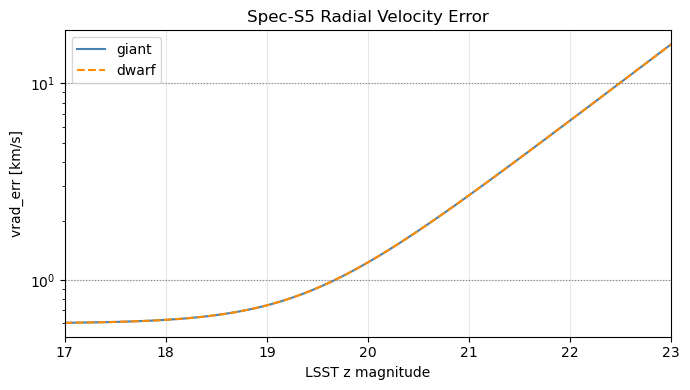

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.semilogy(mags, err_gaia_giant['vrad_err'], label='giant', color='steelblue')
ax.semilogy(mags, err_gaia_dwarf['vrad_err'], label='dwarf', color='darkorange', linestyle='--')

ax.axhline(1,  color='gray', linewidth=0.8, linestyle=':')
ax.axhline(10, color='gray', linewidth=0.8, linestyle=':')
ax.set(xlabel='LSST z magnitude', ylabel='vrad_err [km/s]',
       title='Spec-S5 Radial Velocity Error', xlim=(mags[0], mags[-1]))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Proper motion error

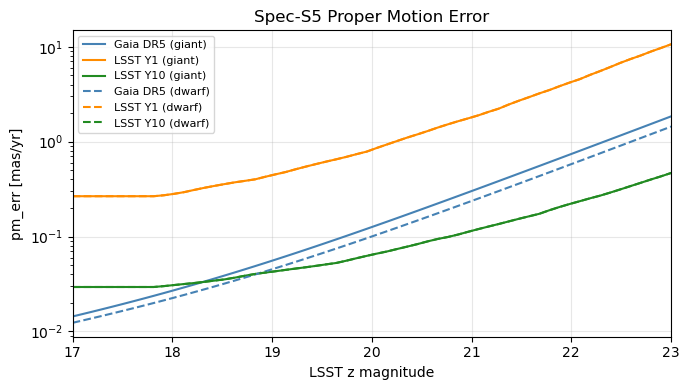

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.semilogy(mags, err_gaia_giant['pm_err'],   label='Gaia DR5 (giant)',   color='steelblue')
ax.semilogy(mags, err_lsst1_giant['pm_err'],  label='LSST Y1 (giant)',    color='darkorange')
ax.semilogy(mags, err_lsst10_giant['pm_err'], label='LSST Y10 (giant)',   color='forestgreen')
ax.semilogy(mags, err_gaia_dwarf['pm_err'],   label='Gaia DR5 (dwarf)',   color='steelblue',   linestyle='--')
ax.semilogy(mags, err_lsst1_dwarf['pm_err'],  label='LSST Y1 (dwarf)',    color='darkorange',  linestyle='--')
ax.semilogy(mags, err_lsst10_dwarf['pm_err'], label='LSST Y10 (dwarf)',   color='forestgreen', linestyle='--')

ax.set(xlabel='LSST z magnitude', ylabel='pm_err [mas/yr]',
       title='Spec-S5 Proper Motion Error', xlim=(mags[0], mags[-1]))
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Fractional distance error

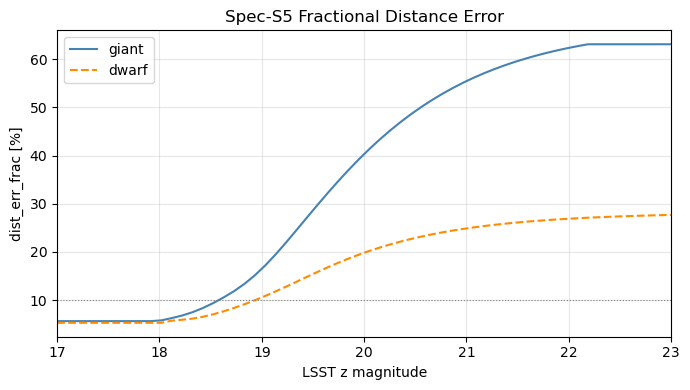

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(mags, err_gaia_giant['dist_err_frac'] * 100, label='giant', color='steelblue')
ax.plot(mags, err_gaia_dwarf['dist_err_frac'] * 100, label='dwarf', color='darkorange', linestyle='--')

ax.axhline(10, color='gray', linewidth=0.8, linestyle=':')
ax.set(xlabel='LSST z magnitude', ylabel='dist_err_frac [%]',
       title='Spec-S5 Fractional Distance Error', xlim=(mags[0], mags[-1]))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## All three errors together

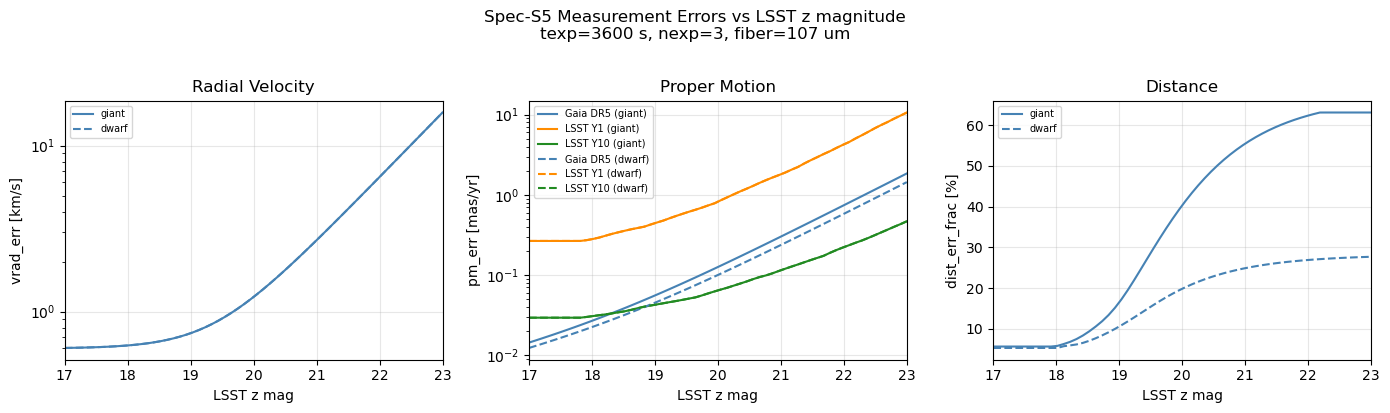

In [6]:
fig, axs = plt.subplots(1, 3, figsize=(14, 4))

for star_type, err_gaia, err_lsst1, err_lsst10, ls in [
    ('giant', err_gaia_giant, err_lsst1_giant, err_lsst10_giant, '-'),
    ('dwarf', err_gaia_dwarf, err_lsst1_dwarf, err_lsst10_dwarf, '--'),
]:
    axs[0].semilogy(mags, err_gaia['vrad_err'],    color='steelblue',   linestyle=ls, label=star_type)
    axs[1].semilogy(mags, err_gaia['pm_err'],      color='steelblue',   linestyle=ls, label=f'Gaia DR5 ({star_type})')
    axs[1].semilogy(mags, err_lsst1['pm_err'],     color='darkorange',  linestyle=ls, label=f'LSST Y1 ({star_type})')
    axs[1].semilogy(mags, err_lsst10['pm_err'],    color='forestgreen', linestyle=ls, label=f'LSST Y10 ({star_type})')
    axs[2].plot(mags, err_gaia['dist_err_frac'] * 100, color='steelblue', linestyle=ls, label=star_type)

axs[0].set(xlabel='LSST z mag', ylabel='vrad_err [km/s]', title='Radial Velocity')
axs[1].set(xlabel='LSST z mag', ylabel='pm_err [mas/yr]', title='Proper Motion')
axs[2].set(xlabel='LSST z mag', ylabel='dist_err_frac [%]', title='Distance')

for ax in axs:
    ax.set_xlim(mags[0], mags[-1])
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.suptitle('Spec-S5 Measurement Errors vs LSST z magnitude\n'
             'texp=3600 s, nexp=3, fiber=107 um', y=1.02)
plt.tight_layout()
plt.show()